In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
imdb_data = pd.read_csv("imdb_movies.csv")

In [5]:
print(imdb_data.shape)

(10178, 12)


In [6]:
imdb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  object 
 1   date_x      10178 non-null  object 
 2   score       10178 non-null  float64
 3   genre       10093 non-null  object 
 4   overview    10178 non-null  object 
 5   crew        10122 non-null  object 
 6   orig_title  10178 non-null  object 
 7   status      10178 non-null  object 
 8   orig_lang   10178 non-null  object 
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  object 
dtypes: float64(3), object(9)
memory usage: 954.3+ KB


In [7]:
imdb_data.isnull().sum()

,0
names,0
date_x,0
score,0
genre,85
overview,0
crew,56
orig_title,0
status,0
orig_lang,0
budget_x,0


In [8]:
imdb_data.describe()

,score,budget_x,revenue
count,10178.000000,1.017800e+04,1.017800e+04
mean,63.497052,6.488238e+07,2.531401e+08
std,13.537012,5.707565e+07,2.777880e+08
min,0.000000,1.000000e+00,0.000000e+00
25%,59.000000,1.500000e+07,2.858898e+07
50%,65.000000,5.000000e+07,1.529349e+08
75%,71.000000,1.050000e+08,4.178021e+08
max,100.000000,4.600000e+08,2.923706e+09


In [9]:
imdb_data["genre"] = imdb_data["genre"].fillna("unavailable")

In [10]:
imdb_data["crew"] = imdb_data["crew"].fillna("unavailable")

In [12]:
imdb_data["date_x"] = pd.to_datetime(imdb_data["date_x"])
imdb_data

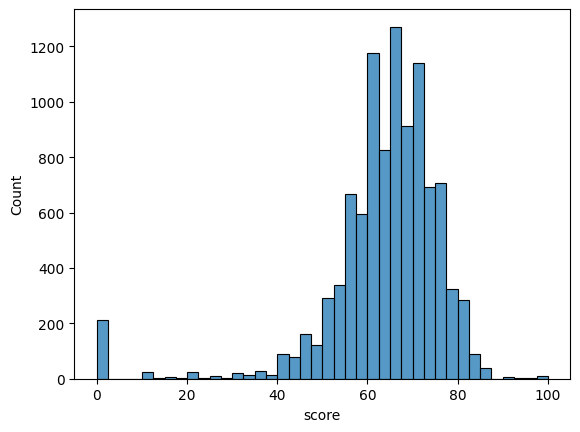

In [15]:
sns.histplot(data = imdb_data, x = "score",bins = 40)
plt.show()

In [18]:
#gc = gener count
gc = imdb_data.groupby("genre").agg({"names" : "count"})
gc = gc.sort_values(by = "names", ascending = False)
gc = gc.head(20)

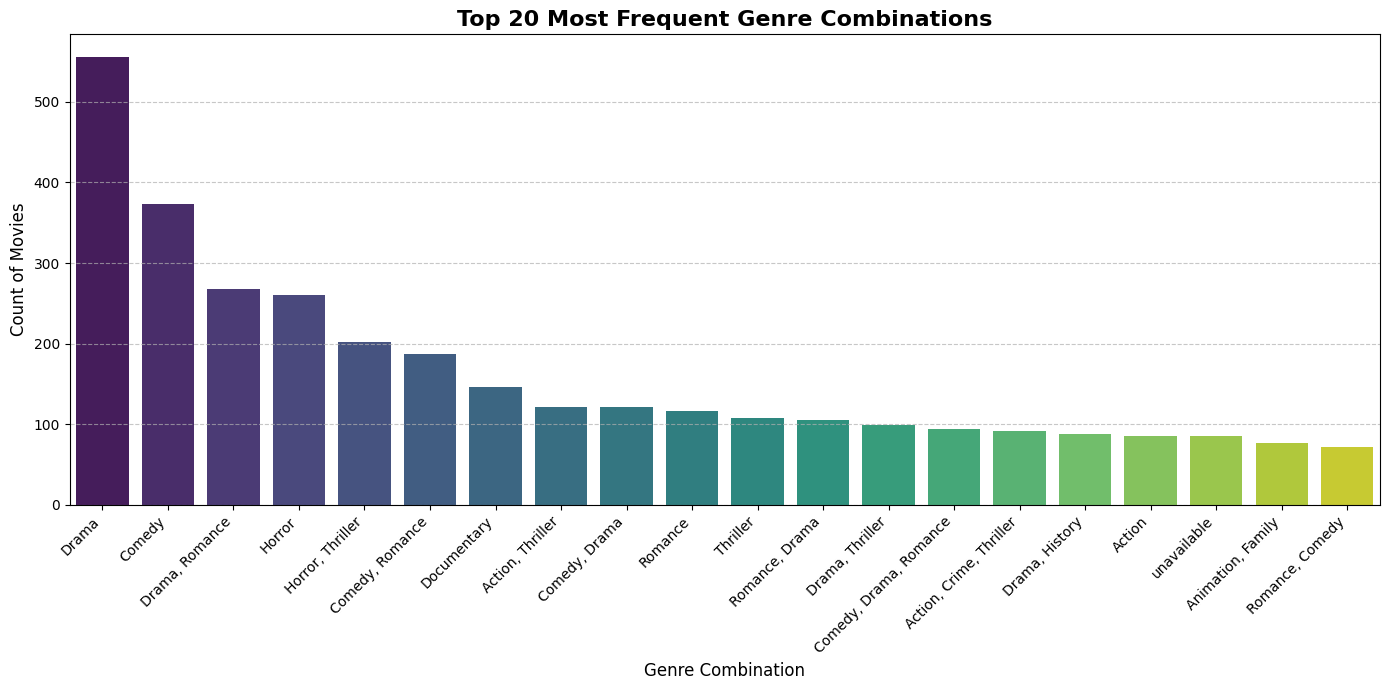

In [21]:
plt.figure(figsize=(14, 7))

genre_counts = gc # Assuming gb is your final aggregated DataFrame

sns.barplot(
    x=genre_counts.index,                  # X-axis: Genre names (the index)
    y=genre_counts['names'],               # Y-axis: The movie count
    palette="viridis",                     # Use the 'viridis' color palette
    hue=genre_counts.index,                # Still using hue for different colors per bar
    legend=False,                          # Hide the redundant legend
    dodge=False                            # Ensures bars are not offset
)

# Add informative title and axis labels
plt.title('Top 20 Most Frequent Genre Combinations', fontsize=16, fontweight='bold')
plt.xlabel('Genre Combination', fontsize=12)
plt.ylabel('Count of Movies', fontsize=12)

# Rotate X-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add a grid line for easier comparison of bar heights
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjusts plot to prevent labels from being cut off
plt.show()

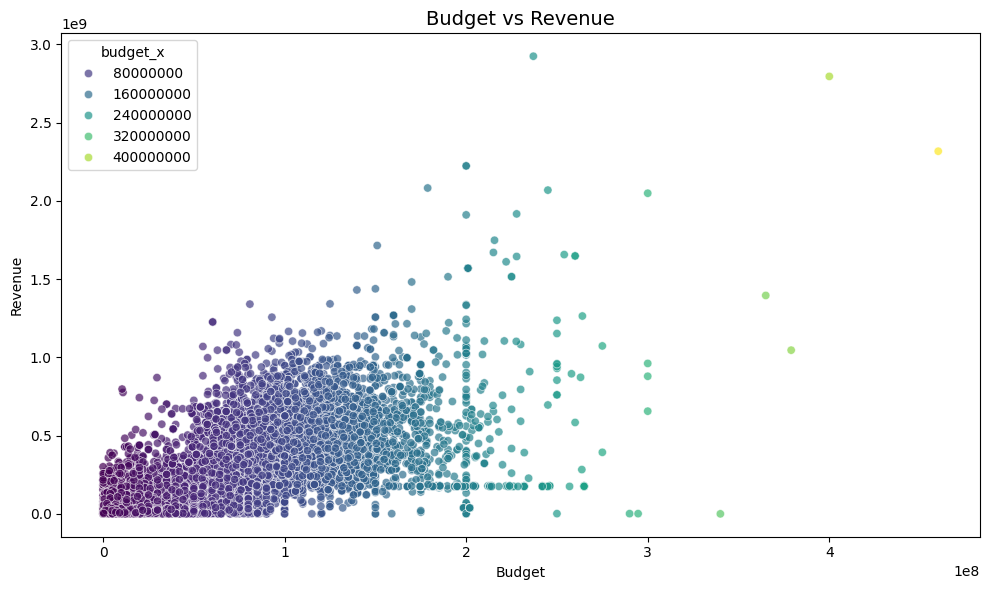

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=imdb_data,
    x="budget_x",
    y="revenue",
    hue="budget_x",
    palette="viridis",
    alpha=0.7
)

plt.title("Budget vs Revenue", fontsize=14)
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()



/tmp/ipython-input-3340040752.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


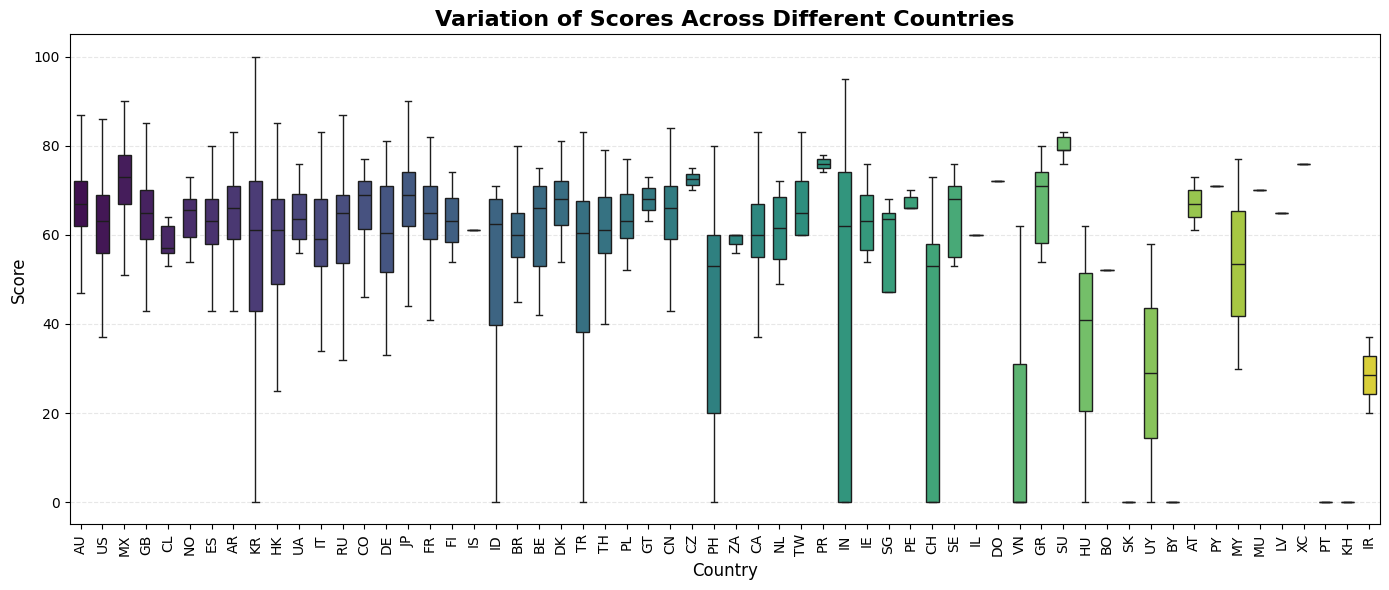

In [28]:
# How do scores vary by country?
# Using a boxplot to visualize the differences in ratings across countries.

plt.figure(figsize=(14,6))

sns.boxplot(
    data=imdb_data,
    x="country",
    y="score",
    palette="viridis",
    width=0.6,
    showfliers=False  # removes extreme outliers for a cleaner view
)

plt.title("Variation of Scores Across Different Countries", fontsize=16, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
df1 = imdb_data[["score","budget_x","revenue"]]
data = df1.corr()

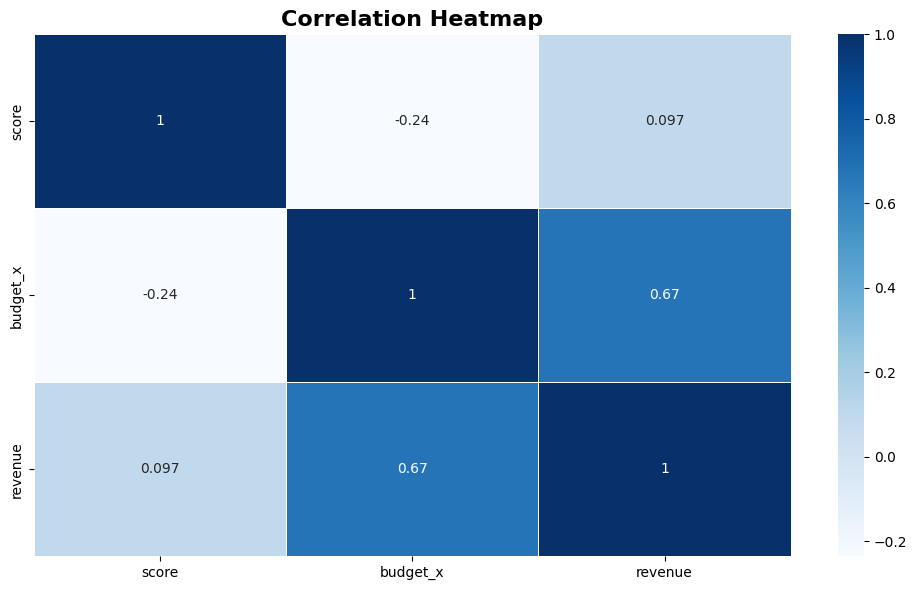

In [32]:
plt.figure(figsize=(10,6))

sns.heatmap(
    data,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


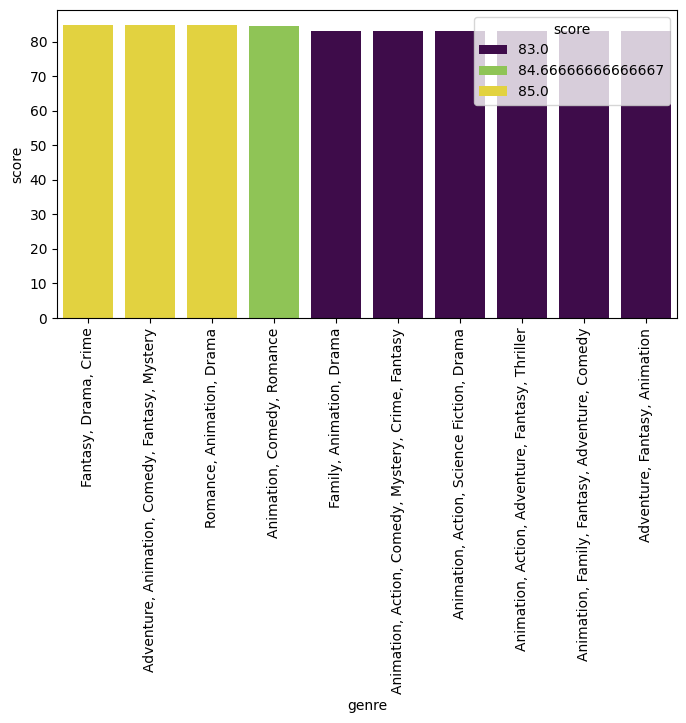

In [36]:
#Which genre has the highest average rating? Calculate the average rating for each genre and plot the results.
gb = imdb_data.groupby("genre").agg({"score":"mean"})
gb = gb.sort_values(by = "score", ascending = False)
gb= gb.head(10)

plt.figure(figsize=(8,4))
sns.barplot(data = gb, x = gb.index, y = gb["score"], hue = "score", palette = "viridis")
plt.xticks(rotation = 90)
plt.show()

In [37]:
imdb_data["year"] = imdb_data["date_x"].dt.strftime("%Y")
imdb_data


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,year
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10173,20th Century Women,2016-12-28,73.0,Drama,"In 1979 Santa Barbara, California, Dorothea Fi...","Annette Bening, Dorothea Fields, Lucas Jade Zu...",20th Century Women,Released,English,7000000.0,9.353729e+06,US,2016
10174,Delta Force 2: The Colombian Connection,1990-08-24,54.0,Action,When DEA agents are taken captive by a ruthles...,"Chuck Norris, Col. Scott McCoy, Billy Drago, R...",Delta Force 2: The Colombian Connection,Released,English,9145817.8,6.698361e+06,US,1990
10175,The Russia House,1990-12-21,61.0,"Drama, Thriller, Romance","Barley Scott Blair, a Lisbon-based editor of R...","Sean Connery, Bartholomew 'Barley' Scott Blair...",The Russia House,Released,English,21800000.0,2.299799e+07,US,1990
10176,Darkman II: The Return of Durant,1995-07-11,55.0,"Action, Adventure, Science Fiction, Thriller, ...",Darkman and Durant return and they hate each o...,"Larry Drake, Robert G. Durant, Arnold Vosloo, ...",Darkman II: The Return of Durant,Released,English,116000000.0,4.756613e+08,US,1995


In [38]:
imdb_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   names       10178 non-null  object        
 1   date_x      10178 non-null  datetime64[ns]
 2   score       10178 non-null  float64       
 3   genre       10178 non-null  object        
 4   overview    10178 non-null  object        
 5   crew        10178 non-null  object        
 6   orig_title  10178 non-null  object        
 7   status      10178 non-null  object        
 8   orig_lang   10178 non-null  object        
 9   budget_x    10178 non-null  float64       
 10  revenue     10178 non-null  float64       
 11  country     10178 non-null  object        
 12  year        10178 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(9)
memory usage: 1.0+ MB


In [39]:
imdb_data["year"] = imdb_data["year"].astype("int")

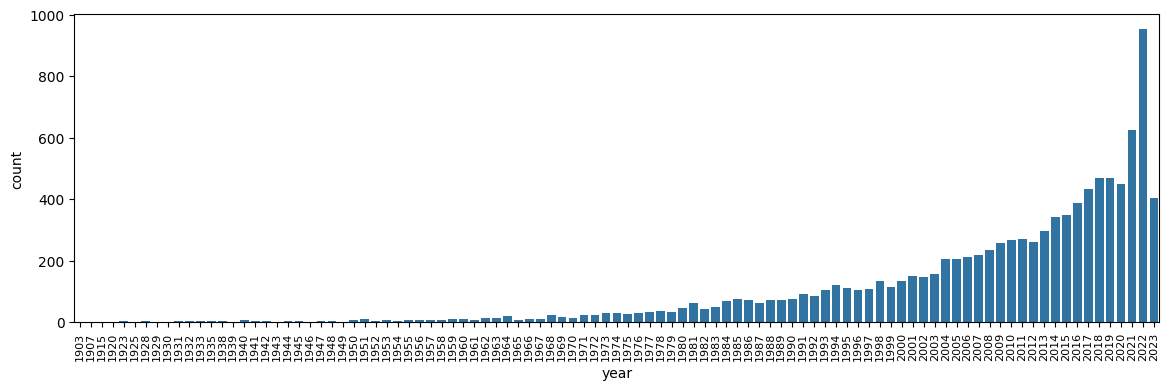

In [40]:
plt.figure(figsize = (14,4))
sns.countplot(x="year", data = imdb_data)
plt.xticks(rotation = 90, fontsize = 8)
plt.show()

In [41]:
gb = imdb_data.groupby(["year","genre"]).agg({"date_x":"count"})
gb

date_x
year genre                                 
1903 Drama, History                       1
1907 Adventure, Science Fiction           1
1915 Drama, History, War                  2
1920 Drama, Horror, Thriller, Crime       1
1923 Comedy, Romance, Thriller            1
...                                     ...
2023 War, Drama, History                  1
     War, History, Drama                  1
     Western                              1
     Western, Action                      1
     unavailable                         24

[6438 rows x 1 columns]

In [43]:
gb = imdb_data.groupby(["year", "genre"]).size()


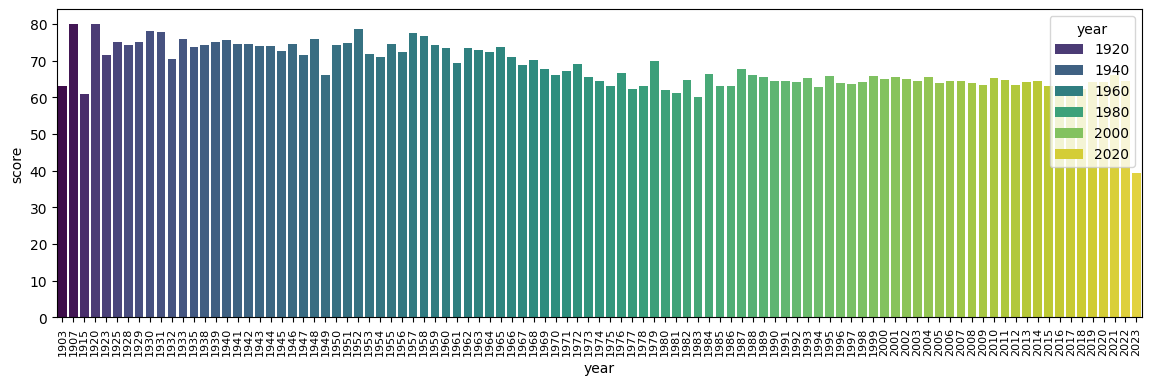

In [44]:
# How has the average movie rating changed over the years? Plot the average rating for each year.

gb = imdb_data.groupby("year").agg({"score" : "mean"})
gb
plt.figure(figsize = (14,4))
sns.barplot(y="score", x = gb.index, data = gb, hue = "year",palette = "viridis")
plt.xticks(rotation = 90, fontsize = 8)
plt.show()

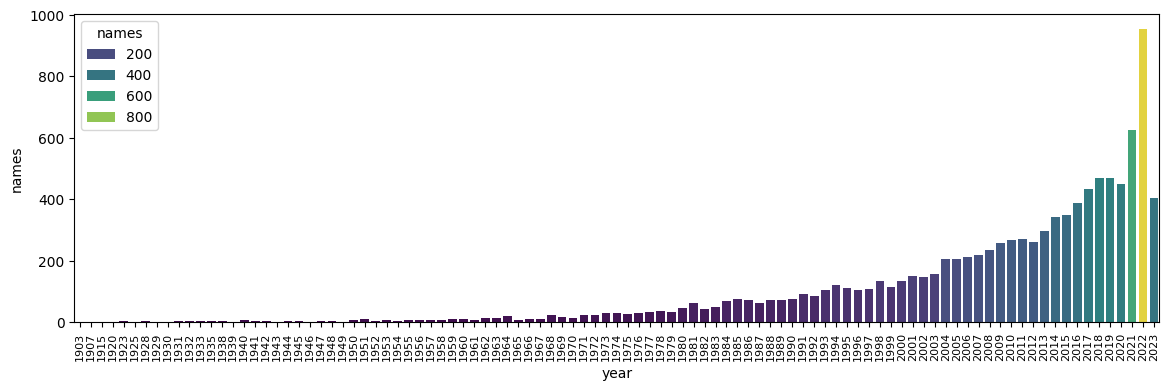

In [45]:
#Which years had the highest and lowest number of movie releases? Plot the number of movies released each year.

gb = imdb_data.groupby("year").agg({"names" : "count"})
gb = gb.sort_values(by = "names", ascending = False)
plt.figure(figsize = (14,4))
sns.barplot(y="names", x = gb.index, data = gb, hue = "names",palette = "viridis")
plt.xticks(rotation = 90, fontsize = 8)
plt.show()

In [47]:
imdb_data["decade"] = (imdb_data["date_x"].dt.year //10)* 10
imdb_data

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,year,decade
0,Creed III,2023-03-02,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU,2023,2020
1,Avatar: The Way of Water,2022-12-15,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU,2022,2020
2,The Super Mario Bros. Movie,2023-04-05,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU,2023,2020
3,Mummies,2023-01-05,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU,2023,2020
4,Supercell,2023-03-17,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US,2023,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10173,20th Century Women,2016-12-28,73.0,Drama,"In 1979 Santa Barbara, California, Dorothea Fi...","Annette Bening, Dorothea Fields, Lucas Jade Zu...",20th Century Women,Released,English,7000000.0,9.353729e+06,US,2016,2010
10174,Delta Force 2: The Colombian Connection,1990-08-24,54.0,Action,When DEA agents are taken captive by a ruthles...,"Chuck Norris, Col. Scott McCoy, Billy Drago, R...",Delta Force 2: The Colombian Connection,Released,English,9145817.8,6.698361e+06,US,1990,1990
10175,The Russia House,1990-12-21,61.0,"Drama, Thriller, Romance","Barley Scott Blair, a Lisbon-based editor of R...","Sean Connery, Bartholomew 'Barley' Scott Blair...",The Russia House,Released,English,21800000.0,2.299799e+07,US,1990,1990
10176,Darkman II: The Return of Durant,1995-07-11,55.0,"Action, Adventure, Science Fiction, Thriller, ...",Darkman and Durant return and they hate each o...,"Larry Drake, Robert G. Durant, Arnold Vosloo, ...",Darkman II: The Return of Durant,Released,English,116000000.0,4.756613e+08,US,1995,1990


In [48]:
# Which genres are most popular in each decade? Create a bar plot showing the most frequent genres by decade.

gb = imdb_data.groupby(["decade", "genre"]).agg({"names":"count"}).reset_index() # for handling the index to use in barplot as there are 3 columns inseat of 2.
gb = gb.sort_values(by = "decade", ascending = False)
gb

,decade,genre,names
3862,2020,"Thriller, TV Movie, Action",1
3882,2020,unavailable,32
3134,2020,Action,20
3135,2020,"Action, Adventure",4
3136,2020,"Action, Adventure, Animation",1
...,...,...,...
5,1920,Drama,2
10,1920,Fantasy,1
2,1910,"Drama, History, War",2
1,1900,"Drama, History",1


In [49]:
# Are there specific genres or release years with higher-rated movies? Group by genre and year, then analyze the average rating.

gb = imdb_data.groupby(["year","genre"]).agg({"score":"mean"}).reset_index()
gb = gb.sort_values(by = "year", ascending = False)
gb

,year,genre,score
6411,2023,"TV Movie, Thriller",70.0
6416,2023,"Thriller, Action, Drama, Crime",60.0
6388,2023,"Music, Comedy, Drama",90.0
6389,2023,"Music, Documentary",26.0
6390,2023,"Mystery, Horror",37.0
...,...,...,...
5,1923,Drama,68.0
3,1920,"Drama, Horror, Thriller, Crime",80.0
2,1915,"Drama, History, War",61.0
1,1907,"Adventure, Science Fiction",80.0


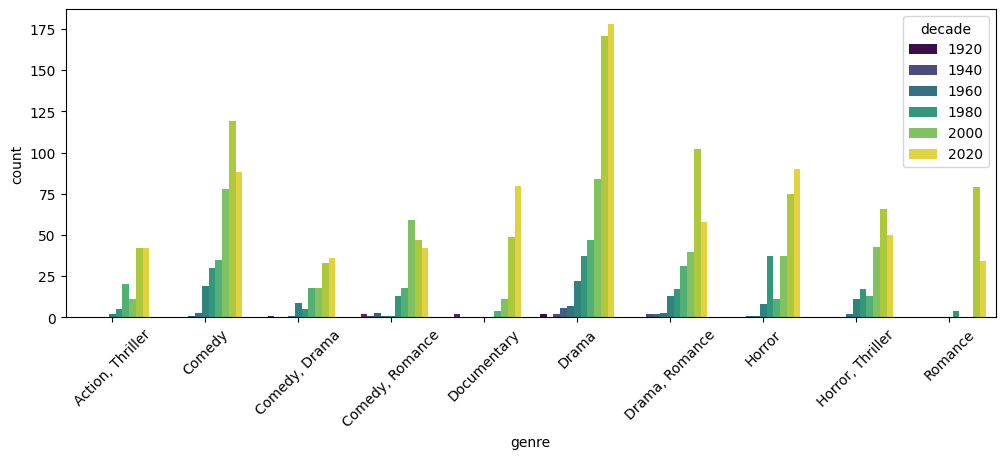

In [52]:
# Count movies by genre and decade
# gb = imdb_data.groupby(["genre", "decade"]).size().reset_index(name="count")

# Take top 10 genres
# top10 = gb.groupby("genre")["count"].sum().nlargest(10).index
# gb = gb[gb["genre"].isin(top10)]

# Simple plot
plt.figure(figsize=(12,4))
sns.barplot(data=gb, x="genre", y="count", hue="decade", palette="viridis")
plt.xticks(rotation=45)
plt.show()


In [55]:

# Take top 10 genres
top10 = gb.groupby("genre")["count"].sum().nlargest(10).index
gb = gb[gb["genre"].isin(top10)]
gb

,genre,decade,count
547,"Action, Thriller",1970,2
548,"Action, Thriller",1980,5
549,"Action, Thriller",1990,20
550,"Action, Thriller",2000,11
551,"Action, Thriller",2010,42
...,...,...,...
3103,"Horror, Thriller",2010,66
3104,"Horror, Thriller",2020,50
3261,Romance,1980,4
3262,Romance,2010,79


In [57]:
# Count movies by genre and decade
gb = imdb_data.groupby(["genre", "decade"]).size().reset_index(name="count")
gb

,genre,decade,count
0,Action,1970,3
1,Action,1980,6
2,Action,1990,13
3,Action,2000,10
4,Action,2010,34
...,...,...,...
3878,unavailable,1980,12
3879,unavailable,1990,10
3880,unavailable,2000,6
3881,unavailable,2010,17


In [ ]:
# "1. Dataset Overview

# The dataset contains detailed information about movies, including their genres, ratings, release dates, and other attributes.
# Each row represents a movie, and each column describes something about that movie such as score, genre, or release year.

# Insights:

# Some columns such as ratings and dates required cleaning.

# Several fields had missing values (like budget or revenue).

# 2. Data Cleaning

# The release date column was converted into a proper datetime format.

# Missing values in important columns were handled so the analysis could be done smoothly.

# 3. Univariate Analysis

# Ratings:
# Most movies received average ratings, with many falling between 6 and 8.

# Genres:
# A few genres appeared very frequently — especially Drama, Action, and Comedy.

# Insights:

# Ratings are not extremely high or extremely low for most movies.

# Popular genres represent both commercial and storytelling-focused films.

# 4. Bivariate Analysis

# Budget vs Revenue:
# Higher budgets generally produced higher revenues. This shows a clear positive link.

# Ratings vs Country:
# Some countries consistently make higher-rated movies than others.

# Correlation:
# Budget and revenue had a much stronger relationship than rating and revenue.

# Insights:

# Money spent on production has a big impact on financial success.

# A high-earning movie does not always mean it is highly rated.

# 5. Genre Analysis

# Best Rated Genres:
# Documentary-style films and Drama tended to receive the highest ratings.

# Genre Popularity Over Time:
# Modern audiences prefer Action and Adventure more than older genres like Westerns.

# Insights:

# Story-driven genres earn stronger ratings.

# Audience interest has shifted toward visually exciting genres.

# 6. Year-Wise and Trend Analysis

# Ratings Over Years:
# Average ratings stayed fairly steady across decades.

# Number of Movies Released:
# Releases increased heavily after the 2000s, showing industry growth.

# Insights:

# Film quality has remained stable even as the industry expanded.

# More movies are being produced now than ever before.

# 7. Multivariate Analysis

# Genres by Decade:
# Some genres, like Sci-Fi and Action, became more frequent in recent decades.
# Drama and Documentary maintained strong ratings across time.

# Insights:

# Trends shift with technology and audience interest.

# Different decades highlight different genre strengths.

# ⭐ Final Key Insights

# Higher budgets lead to higher revenues, making budget an important factor in movie success.

# Ratings have stayed stable across the years, even with more movies being released.

# Genres evolve with time — Action and Adventure dominate recent years.

# Documentary and Drama perform strongly in ratings despite not being the most common genres.

# The film industry has grown significantly, especially after the 2000s."